In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Remove unnecessary column
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Convert target column
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

print(df.isnull().sum())
df.head()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include="object").columns

numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

In [6]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [7]:
lr_cv = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy :", lr_cv.mean())
print("Random Forest CV Accuracy :", rf_cv.mean())

Logistic Regression CV Accuracy : 0.8044875879088973
Random Forest CV Accuracy : 0.7880186826569455


In [8]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[accuracy_score(y_test,lr_pred),accuracy_score(y_test,rf_pred)],
    "Precision":[precision_score(y_test,lr_pred),precision_score(y_test,rf_pred)],
    "Recall":[recall_score(y_test,lr_pred),recall_score(y_test,rf_pred)],
    "F1 Score":[f1_score(y_test,lr_pred),f1_score(y_test,rf_pred)],
    "ROC-AUC":[roc_auc_score(y_test,lr_prob),roc_auc_score(y_test,rf_prob)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
1,Random Forest,0.775018,0.597938,0.465241,0.523308,0.818704


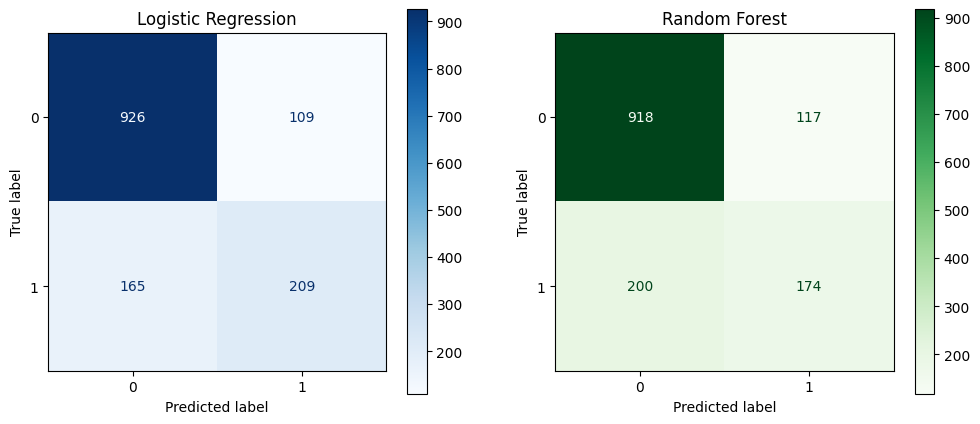

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues",
    ax=ax[0]
)
ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Greens",
    ax=ax[1]
)
ax[1].set_title("Random Forest")

plt.show()

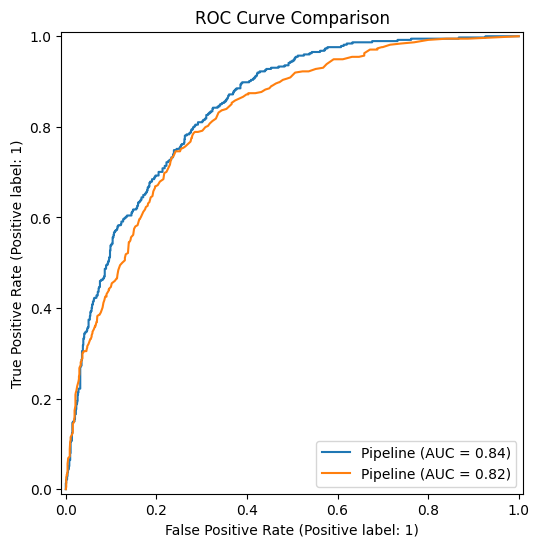

In [10]:
fig, ax = plt.subplots(figsize=(7,6))

RocCurveDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    ax=ax
)

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    ax=ax
)

plt.title("ROC Curve Comparison")
plt.show()

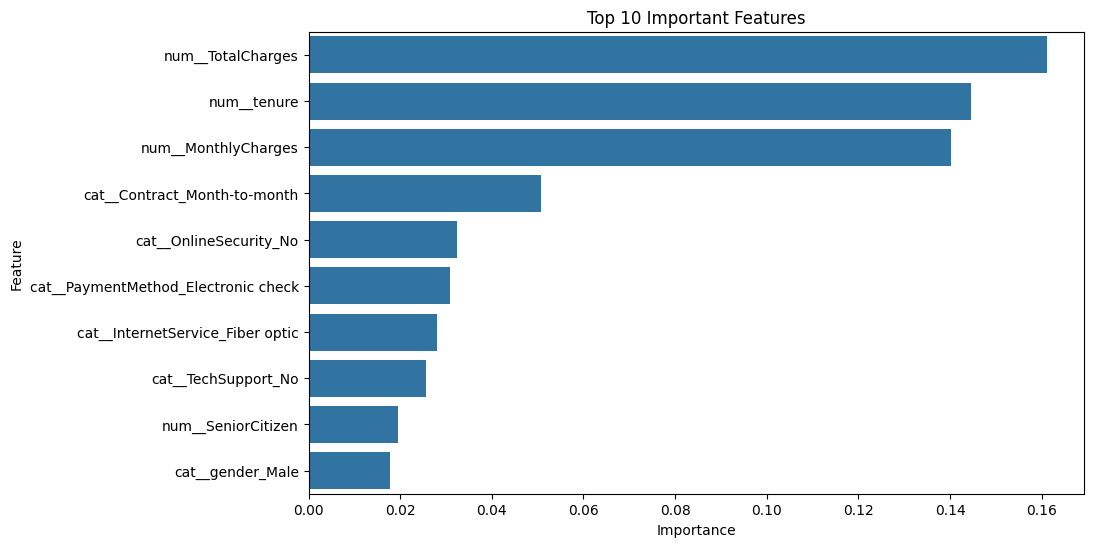

In [11]:
preprocessor.fit(X)

features = preprocessor.get_feature_names_out()

rf = RandomForestClassifier(random_state=42)
rf.fit(preprocessor.transform(X), y)

importance = pd.DataFrame({
    "Feature":features,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

In [12]:
import joblib

joblib.dump(rf_model, "customer_churn_model.pkl")

print("Model saved successfully.")

sample = X.iloc[[0]]

prediction = rf_model.predict(sample)

print("\nPrediction:")

if prediction[0] == 1:
    print("Customer is likely to churn.")
else:
    print("Customer is likely to stay.")

Model saved successfully.

Prediction:
Customer is likely to stay.
